# 06 — Geography & Time Analysis (Block E)
## REVER Logistics Cost & Revenue Analysis — 2025

Answers Block E questions: monthly seasonality, volume vs margin trend, and country-level breakdown.

**Requires:** `01_preparacion.ipynb` to have been run first.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings("ignore")

PROCESSED = Path("../processed")
PALETTE = {
    "primary": "#2C5F8A", "positive": "#2A9D8F", "negative": "#E63946",
    "neutral": "#ADB5BD", "accent": "#F4A261", "bg": "#FFFFFF", "grid": "#F0F0F0",
}
CARRIER_COLORS = {
    "Correos": "#F4A261", "Correos Express": "#E63946",
    "UPS": "#8B5E3C", "GLS": "#2A9D8F", "BRT": "#457B9D",
}
plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"], "axes.facecolor": PALETTE["bg"],
    "axes.grid": True, "grid.color": PALETTE["grid"], "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": True, "axes.spines.bottom": True,
    "axes.edgecolor": "#CCCCCC", "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.frameon": False, "legend.fontsize": 10,
    "figure.dpi": 110, "figure.figsize": (14, 5),
})
FIG_W, FIG_H = 14, 5

merged  = pd.read_parquet(PROCESSED / "merged.parquet")
matched = merged.dropna(subset=["rever_revenue_net"]).copy()
print(f"matched: {len(matched):,} rows | months: {sorted(matched['month'].unique())}")

matched: 244,149 rows | months: ['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12']


---
## E1 — Monthly seasonality: volume, revenue, cost, and margin

Does volume growth come with margin growth? Or only with cost growth?
If margins compress in high-volume months, carriers are not offering volume discounts.

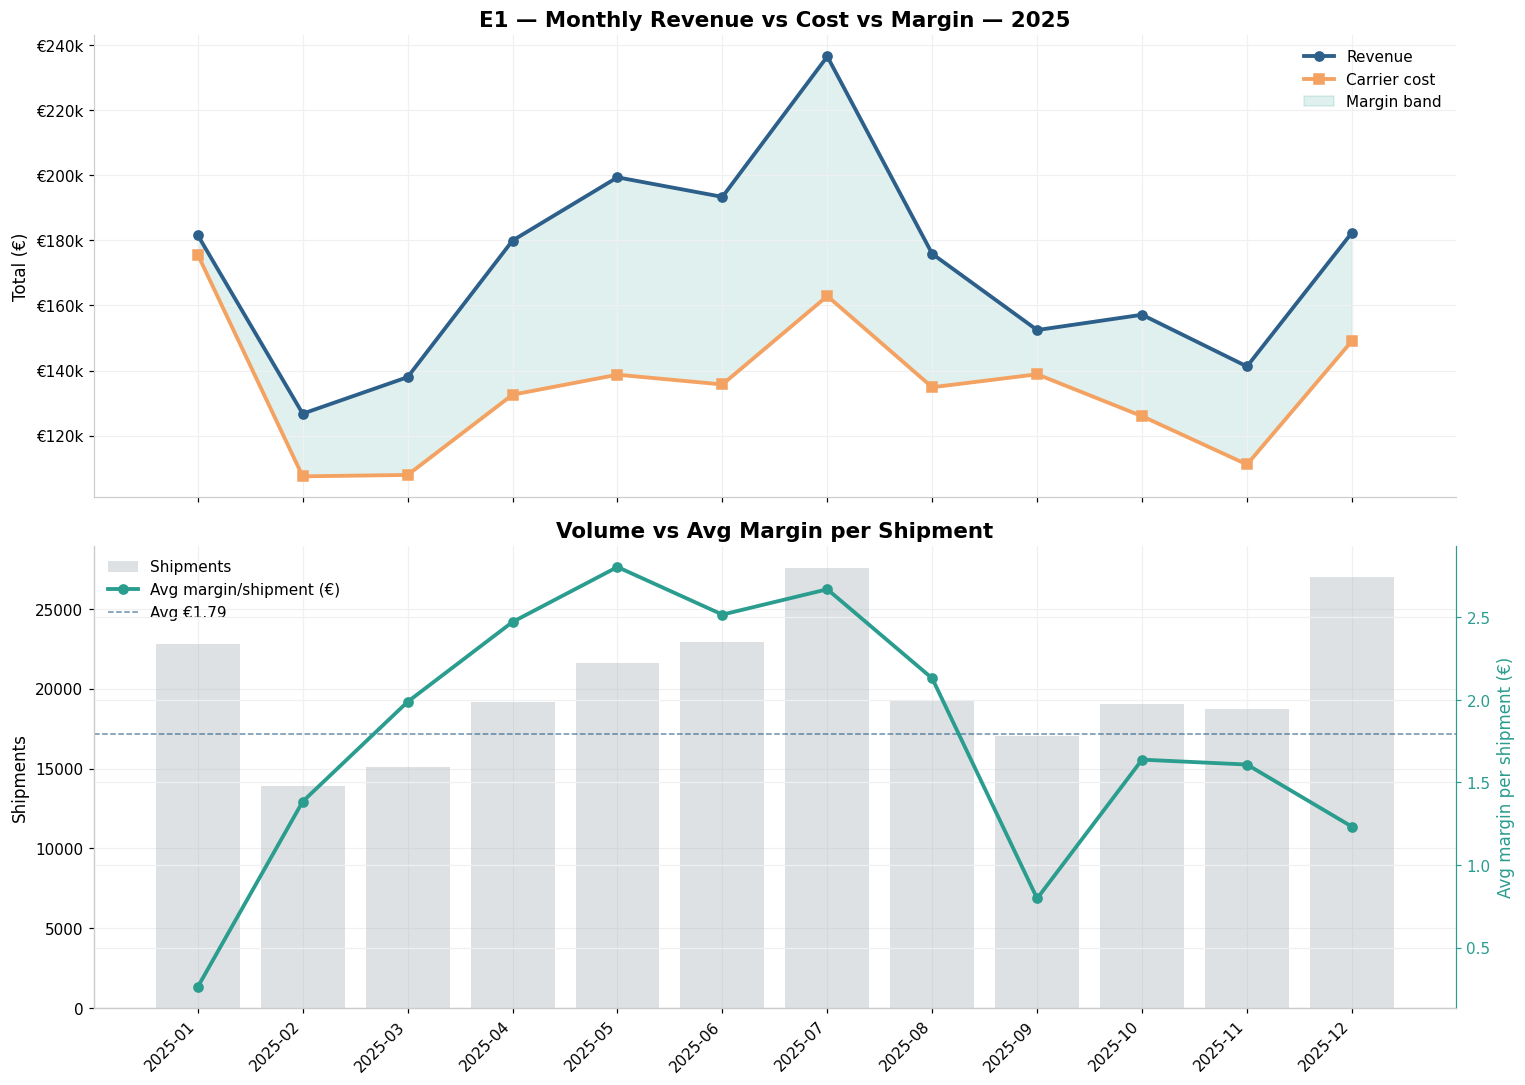

In [2]:
# ── E1: Monthly volume, revenue, cost, and margin evolution ──────────────────
monthly = (
    matched.groupby("month")
    .agg(
        shipments     = ("tracking_id",       "count"),
        total_revenue = ("rever_revenue_net", "sum"),
        total_cost    = ("carrier_cost_net",  "sum"),
        total_margin  = ("margin_eur",        "sum"),
        avg_margin    = ("margin_eur",        "mean"),
    )
    .sort_index()
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(FIG_W, FIG_H * 2), sharex=True)

# Top: revenue, cost, margin as stacked lines
axes[0].plot(monthly["month"], monthly["total_revenue"], marker="o", color=PALETTE["primary"],
             linewidth=2.5, markersize=6, label="Revenue")
axes[0].plot(monthly["month"], monthly["total_cost"],    marker="s", color=PALETTE["accent"],
             linewidth=2.5, markersize=6, label="Carrier cost")
axes[0].fill_between(monthly["month"], monthly["total_cost"], monthly["total_revenue"],
                     alpha=0.15, color=PALETTE["positive"], label="Margin band")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1_000:.0f}k"))
axes[0].set_ylabel("Total (€)")
axes[0].legend()
axes[0].set_title("E1 — Monthly Revenue vs Cost vs Margin — 2025")

# Bottom: avg margin per shipment + shipment bars
ax2 = axes[1].twinx()
axes[1].bar(monthly["month"], monthly["shipments"], color=PALETTE["neutral"], alpha=0.4, label="Shipments", zorder=2)
ax2.plot(monthly["month"], monthly["avg_margin"], marker="o", color=PALETTE["positive"],
         linewidth=2.5, markersize=6, label="Avg margin/shipment (€)", zorder=3)
ax2.axhline(monthly["avg_margin"].mean(), color=PALETTE["primary"], linewidth=1,
            linestyle="--", alpha=0.7, label=f"Avg €{monthly['avg_margin'].mean():.2f}")
axes[1].set_ylabel("Shipments")
ax2.set_ylabel("Avg margin per shipment (€)", color=PALETTE["positive"])
ax2.tick_params(axis="y", colors=PALETTE["positive"])
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_color(PALETTE["positive"])
lines1, l1 = axes[1].get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, l1 + l2, loc="upper left")
axes[1].set_xticklabels(monthly["month"], rotation=45, ha="right")
axes[1].set_title("Volume vs Avg Margin per Shipment")

plt.tight_layout()
plt.show()

---
## E2 — Country breakdown: volume and margin

Which countries generate the most shipments and the most margin?
Also: is there a country where the margin per shipment is consistently low (pricing issue or expensive routes)?

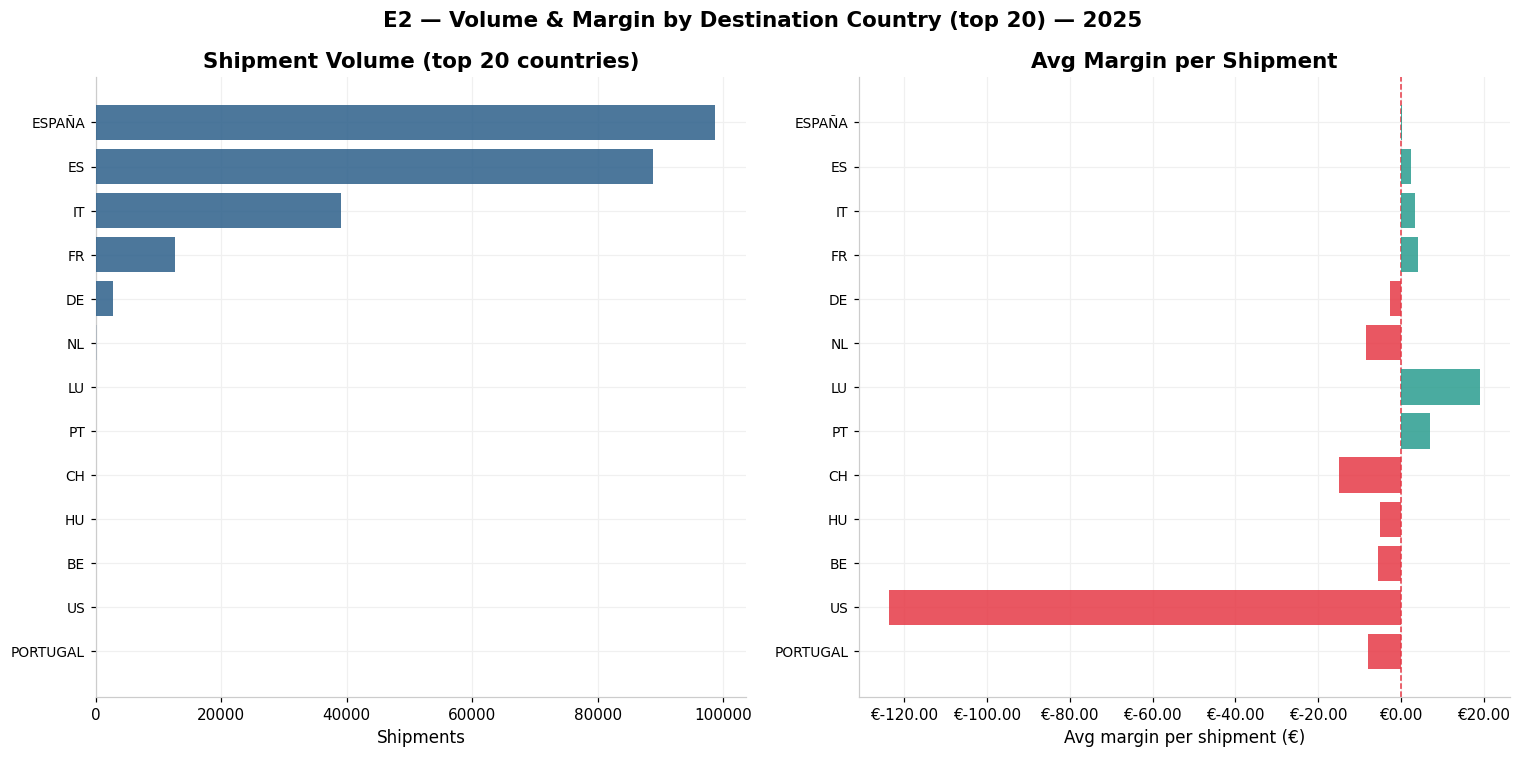

In [3]:
# ── E2: Country breakdown — volume and avg margin ─────────────────────────────
# Use destination_country from carrier data; fallback to merchant_country from REVER
country_col = "destination_country" if "destination_country" in matched.columns else "merchant_country"

country = (
    matched.dropna(subset=[country_col])
    .groupby(country_col)
    .agg(
        shipments      = ("tracking_id",       "count"),
        total_margin   = ("margin_eur",        "sum"),
        avg_margin_eur = ("margin_eur",        "mean"),
    )
    .reset_index()
    .sort_values("shipments", ascending=False)
    .head(20)
    .rename(columns={country_col: "country"})
)

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H + 2))

# Left: shipment volume
colors_vol = [PALETTE["primary"] if i < 5 else PALETTE["neutral"] for i in range(len(country))]
axes[0].barh(range(len(country)), country["shipments"], color=colors_vol, alpha=0.85, zorder=3)
axes[0].set_yticks(range(len(country)))
axes[0].set_yticklabels(country["country"], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("Shipments")
axes[0].set_title("Shipment Volume (top 20 countries)")

# Right: avg margin per shipment
colors_mg = [PALETTE["positive"] if m > 0 else PALETTE["negative"] for m in country["avg_margin_eur"]]
axes[1].barh(range(len(country)), country["avg_margin_eur"], color=colors_mg, alpha=0.85, zorder=3)
axes[1].axvline(0, color=PALETTE["negative"], linewidth=1, linestyle="--")
axes[1].set_yticks(range(len(country)))
axes[1].set_yticklabels(country["country"], fontsize=9)
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:.2f}"))
axes[1].set_xlabel("Avg margin per shipment (€)")
axes[1].set_title("Avg Margin per Shipment")

fig.suptitle("E2 — Volume & Margin by Destination Country (top 20) — 2025", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## E2 (why) — Country × carrier: avg cost per shipment

Is a carrier systematically more expensive for a specific country?
This reveals misassigned routes — a carrier that is cheap domestically but expensive internationally.

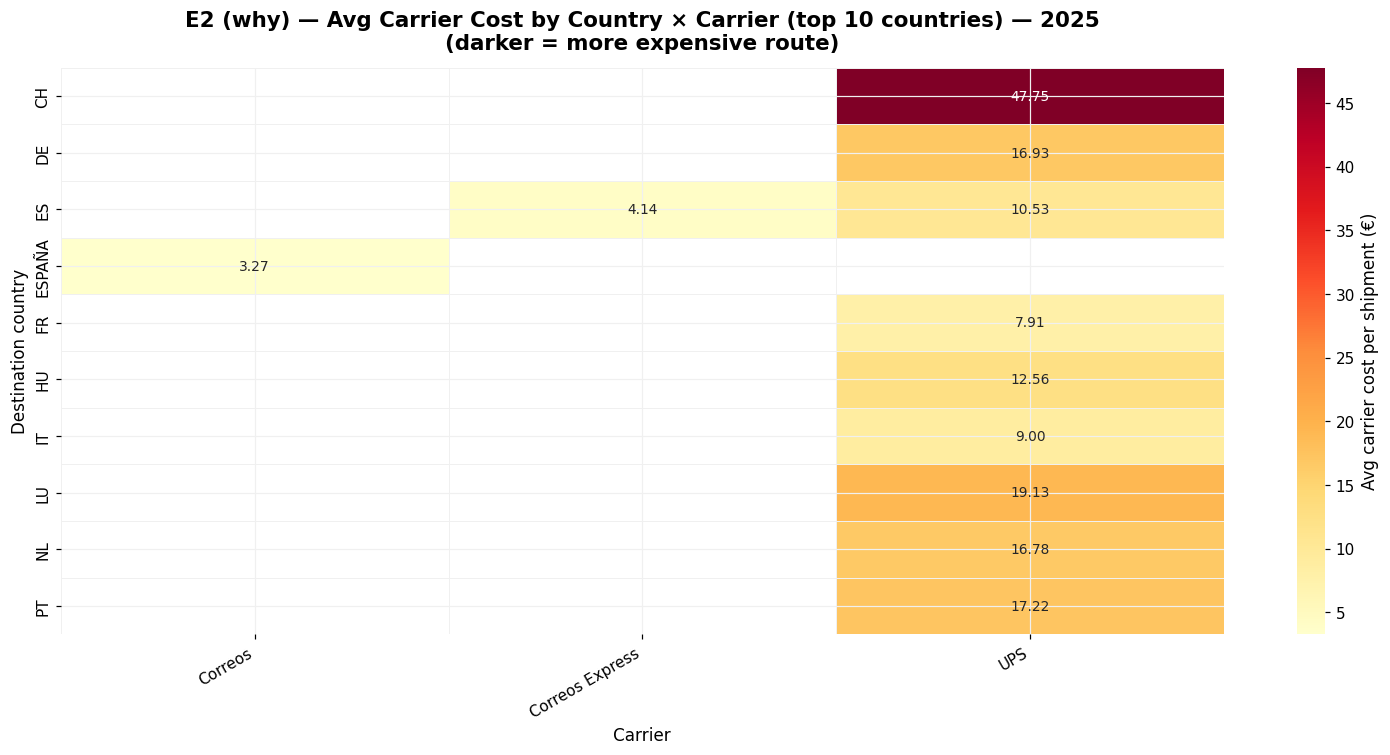

In [4]:
# ── E2 (why): Country × carrier avg cost heatmap (top 10 countries) ──────────
country_col = "destination_country" if "destination_country" in matched.columns else "merchant_country"
top10 = (
    matched.dropna(subset=[country_col])
    .groupby(country_col)["tracking_id"].count()
    .sort_values(ascending=False).head(10).index.tolist()
)
cc = (
    matched[matched[country_col].isin(top10)]
    .groupby([country_col, "carrier"])["carrier_cost_net"]
    .mean()
    .reset_index()
    .pivot(index=country_col, columns="carrier", values="carrier_cost_net")
)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 2))
sns.heatmap(
    cc, ax=ax, cmap="YlOrRd", annot=True, fmt=".2f",
    annot_kws={"size": 9},
    linewidths=0.4, linecolor=PALETTE["grid"],
    cbar_kws={"label": "Avg carrier cost per shipment (€)"},
)
ax.set_xlabel("Carrier")
ax.set_ylabel("Destination country")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_title("E2 (why) — Avg Carrier Cost by Country × Carrier (top 10 countries) — 2025\n(darker = more expensive route)", pad=12)
plt.tight_layout()
plt.show()